# PCA Portfolios in Risk Regimes — Can regime awareness make principal portfolios investable and profitable?
**Saverio Lauriola — Research notebook**

This notebook implements a clean, *non-leaky* pipeline for:
- **PCA (static and walk-forward)** on a US tech equity universe
- **Investable factor-mimicking “principal portfolios”** built from PCA on the **correlation matrix**
- A single **global state variable** (implied volatility) used to define **risk regimes**
- **Non-leaky regime labels** via expanding quantiles (trained only on past information)
- **Stationary block bootstrap** (Politis–Romano) to estimate uncertainty bands for risk/return metrics (overall and regime-conditional)
- **Portfolio stability and implementability diagnostics**: turnover and **weight stability** (cosine similarity)

**Goal.** Test whether any principal portfolio exhibits regime-dependent dominance (e.g., higher-order PCs in HIGH risk) to motivate a *regime rotation* strategy, or whether a **buy-and-hold PC1** baseline is preferable once stability/turnover are accounted for.

**Key findings**. Summarized in the repository README (PC1 baseline; higher PCs improve risk-adjusted metrics only in HIGH regimes but are less stable with higher turnover).

**Notes**
- *Conditional performance* = metrics computed **only on regime days** (no risk-free padding).
- *Tradable strategy* = define behavior outside a regime (cash/benchmark/overlay) and include turnover & transaction costs.

> This repository hosts the current research version. Extensions are tracked in TODOs.

## Helper functions



In [ ]:
# ============================================================
# HELPERS (keep everything reusable here)
# ============================================================

from yfinance import download
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


def linear_returns_from_prices(adj_close: pd.DataFrame) -> pd.DataFrame:
    return adj_close.pct_change().dropna(how="all")

def ewma_mean_std(x: pd.Series, lam: float = 0.94) -> pd.DataFrame:
    x = x.dropna().astype(float)
    m = np.zeros(len(x))
    v = np.zeros(len(x))
    m[0] = x.iloc[0]
    v[0] = 0.0
    for t in range(1, len(x)):
        m[t] = lam * m[t-1] + (1 - lam) * x.iloc[t]
        innov = x.iloc[t] - m[t-1]
        v[t] = lam * v[t-1] + (1 - lam) * innov**2
    s = np.sqrt(np.maximum(v, 1e-12))
    return pd.DataFrame({"ewma_mean": m, "ewma_std": s}, index=x.index)

def build_state_z_from_iv(iv_level: pd.Series,
                          freq: str = "D",
                          smooth_window: int = 5,
                          lam: float = 0.94,
                          use_zscore: bool = True) -> pd.Series:
    # Build z_t from implied vol level:
    #   x_t = log(IV_t)
    #   smooth(x_t) = rolling mean over past 'smooth_window' periods (incl. today)
    #   z_t = (smooth - ewma_mean) / ewma_std   (optional)
    iv = iv_level.dropna().astype(float)
    if freq.upper().startswith("W"):
        iv = iv.resample("W-FRI").last()  # align to week close
    x = np.log(iv)
    x_smooth = x.rolling(window=smooth_window, min_periods=smooth_window).mean().dropna()

    if not use_zscore:
        z = x_smooth.copy()
        z.name = "state_z"
        return z

    stats = ewma_mean_std(x_smooth, lam=lam)
    z = (x_smooth.loc[stats.index] - stats["ewma_mean"]) / stats["ewma_std"]
    z.name = "state_z"
    return z

def regime_labels_from_state(z: pd.Series,
                             q=(0.33, 0.66),
                             expanding: bool = True,
                             min_obs: int = 252) -> pd.Series:
    # Non-leaky LOW/MID/HIGH labels from z_t via expanding quantiles.
    z = z.dropna().astype(float)
    labels = pd.Series(index=z.index, dtype="object")

    q1, q2 = q
    if not expanding:
        a, b = z.quantile(q1), z.quantile(q2)  # leaky benchmark
        labels[z <= a] = "LOW"
        labels[(z > a) & (z <= b)] = "MID"
        labels[z > b] = "HIGH"
        return labels

    for i in range(len(z)):
        if i + 1 < min_obs:
            continue
        hist = z.iloc[: i + 1]
        a, b = hist.quantile(q1), hist.quantile(q2)
        zi = z.iloc[i]
        if zi <= a:
            labels.iloc[i] = "LOW"
        elif zi <= b:
            labels.iloc[i] = "MID"
        else:
            labels.iloc[i] = "HIGH"
    return labels.dropna()

def weighted_mean_cov(X: pd.DataFrame, p: pd.Series | None = None):
    # Mean/cov with optional probabilities p (must sum to 1 on index).
    if p is None:
        mu = X.mean(axis=0).values
        Xc = X.values - mu.reshape(1, -1)
        Sigma = (Xc.T @ Xc) / X.shape[0]
        return pd.Series(mu, index=X.columns, name="mu"), pd.DataFrame(Sigma, index=X.columns, columns=X.columns)

    X = X.loc[p.index].copy()
    w = p.values.reshape(-1, 1)
    mu = (w * X.values).sum(axis=0)
    Xc = X.values - mu.reshape(1, -1)
    Sigma = (w * Xc).T @ Xc
    return pd.Series(mu, index=X.columns, name="mu"), pd.DataFrame(Sigma, index=X.columns, columns=X.columns)

def correlation_pca(Sigma: np.ndarray):
    # Correlation PCA: rho = D^{-1} Sigma D^{-1}.
    Sigma = np.asarray(Sigma, dtype=float)
    vol = np.sqrt(np.clip(np.diag(Sigma), 1e-18, None))
    Dinv = np.diag(1.0 / vol)
    rho = Dinv @ Sigma @ Dinv
    lam, V = np.linalg.eigh(rho)   # ascending
    lam = lam[::-1]
    V = V[:, ::-1]

    # Sign convention: largest abs element in each eigenvector positive
    max_abs_row = np.argmax(np.abs(V), axis=0)
    s = np.sign(V[max_abs_row, np.arange(V.shape[0])])
    s[s == 0] = 1.0
    V = V * s.reshape(1, -1)
    return lam, V, vol, rho

def pc_portfolio_weights_from_corr_pca(V: np.ndarray, vol: np.ndarray, gross_norm: float = 1.0) -> pd.DataFrame:
    # Investible PC portfolios: w_k ∝ D^{-1} v_k, then normalize to sum(abs(w))=gross_norm.
    V = np.asarray(V, dtype=float)
    vol = np.asarray(vol, dtype=float)
    Dinv = 1.0 / vol
    W = V * Dinv.reshape(-1, 1)
    gross = np.sum(np.abs(W), axis=0)
    gross[gross == 0] = 1.0
    W = W / gross.reshape(1, -1) * gross_norm
    return pd.DataFrame(W)

def factor_returns(R: pd.DataFrame, W: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame(R.values @ W.values, index=R.index, columns=[f"PC{i+1}" for i in range(W.shape[1])])

# ---------- Basic utilities ----------
def max_drawdown_from_wealth(wealth: pd.Series) -> float:
    wealth = wealth.dropna().astype(float)
    peak = wealth.cummax()
    dd = wealth/peak - 1.0
    return float(dd.min()) if len(dd) else np.nan

def ulcer_index(r: pd.Series) -> float:
    r = r.dropna().astype(float)
    if len(r)==0:
        return np.nan
    wealth = (1.0 + r).cumprod()
    peak = wealth.cummax()
    dd = wealth/peak - 1.0
    return float(np.sqrt(np.mean(dd**2)))

def cagr(r: pd.Series, ann: int = 252) -> float:
    r = r.dropna().astype(float)
    if len(r)==0:
        return np.nan
    wealth = (1.0 + r).cumprod()
    years = len(r)/ann
    return float(wealth.iloc[-1]**(1/years)-1) if years>0 else np.nan

# ---------- Performance metrics (you asked: include CAGR + Martin, always) ----------
def perf_metrics(r: pd.Series, rf_daily: float = 0.0, ann: int = 252) -> dict:
    r = r.dropna().astype(float)
    if len(r) < 5:
        return {"n": int(len(r))}

    # Excess returns for Sharpe/Sortino (clean definition)
    ex = r - rf_daily

    mu_d = ex.mean()
    vol_d = ex.std(ddof=1)
    shr = (mu_d/vol_d)*np.sqrt(ann) if vol_d>0 else np.nan

    downside = ex.copy()
    downside[downside > 0] = 0.0
    dvol = downside.std(ddof=1)
    sor = (mu_d/dvol)*np.sqrt(ann) if dvol>0 else np.nan

    cagr_ = cagr(r, ann=ann)
    wealth = (1.0 + r).cumprod()
    mxdd = max_drawdown_from_wealth(wealth)
    calmar = (cagr_/abs(mxdd)) if (mxdd < 0 and np.isfinite(mxdd)) else np.nan

    ui = ulcer_index(r)
    rf_ann = (1.0 + rf_daily)**ann - 1.0
    martin = ((cagr_ - rf_ann)/ui) if (ui>0 and np.isfinite(ui)) else np.nan

    return {
        "n": int(len(r)),
        "CAGR": float(cagr_),
        "MxDD": float(mxdd),
        "ShR": float(shr),
        "SoR": float(sor),
        "Calmar": float(calmar),
        "Ulcer": float(ui),
        "Martin": float(martin),
    }

# ---------- Regimes ----------
def regime_from_state(z: pd.Series, q_low: float = 0.33, q_high: float = 0.66) -> pd.Series:
    z = z.dropna().astype(float)
    lo = z.quantile(q_low)
    hi = z.quantile(q_high)
    reg = pd.Series(index=z.index, dtype="object")
    reg[z <= lo] = "LOW"
    reg[(z > lo) & (z < hi)] = "MID"
    reg[z >= hi] = "HIGH"
    return reg

# ---------- Metrics tables (overall + conditional) ----------
def compute_metrics_by_regime(F: pd.DataFrame, reg: pd.Series, rf_daily: float = 0.0, ann: int = 252) -> dict:
    reg = reg.reindex(F.index).dropna()
    F = F.loc[reg.index]
    out = {"overall": {c: perf_metrics(F[c], rf_daily=rf_daily, ann=ann) for c in F.columns}}
    for rn in ["LOW","MID","HIGH"]:
        idx = reg[reg==rn].index
        out[rn] = {c: perf_metrics(F.loc[idx, c], rf_daily=rf_daily, ann=ann) for c in F.columns}
    return out

def table_from_metrics(mdict: dict, key: str) -> pd.DataFrame:
    rows=[]
    for regime_name, d in mdict.items():
        for pc, mets in d.items():
            rows.append({"regime": regime_name, "PC": pc, key: mets.get(key, np.nan)})
    return pd.DataFrame(rows).pivot(index="PC", columns="regime", values=key)

# ---------- Turnover / similarity ----------
def turnover(w_prev: np.ndarray, w_now: np.ndarray) -> float:
    w_prev = np.asarray(w_prev, float).ravel()
    w_now  = np.asarray(w_now, float).ravel()
    return float(np.sum(np.abs(w_now - w_prev)))

def cosine_sim(a: np.ndarray, b: np.ndarray) -> float:
    a = np.asarray(a, float).ravel()
    b = np.asarray(b, float).ravel()
    na = np.linalg.norm(a); nb = np.linalg.norm(b)
    if na==0 or nb==0:
        return np.nan
    return float(np.dot(a,b)/(na*nb))

def align_signs_to_previous(W_prev: np.ndarray, W_now: np.ndarray) -> np.ndarray:
    # column-wise sign alignment using cosine similarity
    W_now = W_now.copy()
    for j in range(W_now.shape[1]):
        if cosine_sim(W_prev[:,j], W_now[:,j]) < 0:
            W_now[:,j] *= -1
    return W_now

def stability_from_W_hist(W_hist: list, pcs: list) -> pd.DataFrame:
    if len(W_hist) < 2:
        return pd.DataFrame()
    rows=[]
    for i in range(1, len(W_hist)):
        W_prev = W_hist[i-1]["W"][pcs].values
        W_now  = W_hist[i]["W"][pcs].values
        W_now  = align_signs_to_previous(W_prev, W_now)
        row={"rebalance": W_hist[i]["rebalance"]}
        for j,pc in enumerate(pcs):
            row[f"cos_{pc}"] = cosine_sim(W_prev[:,j], W_now[:,j])
            row[f"to_{pc}"]  = turnover(W_prev[:,j], W_now[:,j])
        rows.append(row)
    return pd.DataFrame(rows).set_index("rebalance")

# ---------- Politis–Romano stationary bootstrap ----------
def stationary_bootstrap_indices(T: int, avg_block_len: float, rng: np.random.Generator) -> np.ndarray:
    # Politis & Romano: block length geometric with mean avg_block_len
    p = 1.0/avg_block_len
    idx = np.empty(T, dtype=int)
    idx[0] = rng.integers(0, T)
    for t in range(1, T):
        if rng.random() < p:
            idx[t] = rng.integers(0, T)
        else:
            idx[t] = (idx[t-1] + 1) % T
    return idx

def stationary_bootstrap_df(df: pd.DataFrame, n_boot: int = 1000, avg_block_len: float = 10.0, seed: int = 1):
    rng = np.random.default_rng(seed)
    T = len(df)
    for _ in range(n_boot):
        ii = stationary_bootstrap_indices(T, avg_block_len, rng)
        yield df.iloc[ii].reset_index(drop=True)

def summarize_vec(x: np.ndarray) -> pd.Series:
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    if len(x)==0:
        return pd.Series({"mean": np.nan, "p05": np.nan, "p50": np.nan, "p95": np.nan, "n": 0})
    return pd.Series({
        "mean": float(np.mean(x)),
        "p05": float(np.quantile(x, 0.05)),
        "p50": float(np.quantile(x, 0.50)),
        "p95": float(np.quantile(x, 0.95)),
        "n": int(len(x))
    })

def bootstrap_metric_tables(df_joint: pd.DataFrame,
                           pc_cols: list,
                           z_col: str = "z",
                           regime_q=(0.33,0.66),
                           metrics=("CAGR","ShR","SoR","Calmar","Martin","MxDD"),
                           n_boot: int = 1000,
                           avg_block_len: float = 10.0,
                           seed: int = 1,
                           rf_daily: float = 0.0,
                           ann: int = 252) -> dict:
    # returns dict[(metric, regime)] -> table PCs x {mean,p05,p50,p95,n}
    out={}
    sims = stationary_bootstrap_df(df_joint, n_boot=n_boot, avg_block_len=avg_block_len, seed=seed)
    mats={(m,rn): np.full((n_boot, len(pc_cols)), np.nan) for m in metrics for rn in ["overall","LOW","MID","HIGH"]}
    for i, sim in enumerate(sims):
        z = sim[z_col]
        reg = regime_from_state(z, q_low=regime_q[0], q_high=regime_q[1])
        F = sim[pc_cols]
        md = compute_metrics_by_regime(F, reg, rf_daily=rf_daily, ann=ann)
        for rn in ["overall","LOW","MID","HIGH"]:
            for j,pc in enumerate(pc_cols):
                for m in metrics:
                    mats[(m,rn)][i,j] = md[rn][pc].get(m, np.nan)
    for m in metrics:
        for rn in ["overall","LOW","MID","HIGH"]:
            rows=[]
            for j,pc in enumerate(pc_cols):
                s = summarize_vec(mats[(m,rn)][:,j]); s["PC"]=pc
                rows.append(s)
            out[(m,rn)] = pd.DataFrame(rows).set_index("PC").sort_values("mean", ascending=False)
    return out


# -------------------------
# Stationary Bootstrap (Politis–Romano)
# -------------------------
def stationary_bootstrap_indices(T: int, avg_block_len: float, rng: np.random.Generator):
    p = 1.0 / avg_block_len
    idx = np.empty(T, dtype=int)
    idx[0] = rng.integers(0, T)
    for t in range(1, T):
        if rng.random() < p:
            idx[t] = rng.integers(0, T)
        else:
            idx[t] = (idx[t-1] + 1) % T
    return idx

def stationary_bootstrap_series(df: pd.DataFrame, n_boot: int = 2000, avg_block_len: float = 10.0, seed: int = 0):
    rng = np.random.default_rng(seed)
    T = len(df)
    out = []
    for _ in range(n_boot):
        idx = stationary_bootstrap_indices(T, avg_block_len, rng)
        out.append(df.iloc[idx].reset_index(drop=True))
    return out

# -------------------------
# Politis–White style automatic block length (data-driven)
# -------------------------

def _autocov(x: np.ndarray, lag: int) -> float:
    """Sample autocovariance at lag (unbiased-ish)."""
    x = np.asarray(x, float)
    n = len(x)
    if lag >= n:
        return np.nan
    x0 = x[: n - lag]
    x1 = x[lag:]
    return float(np.mean((x0 - x0.mean()) * (x1 - x1.mean())))

def _long_run_var_bartlett(x: np.ndarray, L: int) -> float:

    g0 = _autocov(x, 0)
    s = g0
    for k in range(1, L + 1):
        wk = 1.0 - k / (L + 1.0)
        gk = _autocov(x, k)
        s += 2.0 * wk * gk
    return float(max(s, 1e-18))

def politis_white_block_length(
    s: pd.Series,
    use_abs: bool = True,
    max_lag: int | None = None,
    clip: tuple[int, int] = (2, 252),
) -> int:

    x = s.dropna().astype(float).values
    if use_abs:
        x = np.abs(x)

    T = len(x)
    if T < 50:
        # Too short: return something conservative
        return int(np.clip(10, *clip))

    # Choose truncation lag for long-run variance estimation (rule of thumb)
    if max_lag is None:
        max_lag = int(np.floor(T ** (1 / 3)))
        max_lag = max(5, min(max_lag, 200))

    # Long-run variance (captures dependence)
    lrv = _long_run_var_bartlett(x, L=max_lag)
    var = float(np.var(x, ddof=1))
    var = max(var, 1e-18)

    # Heuristic Politis–White style scaling:
    # L* ∝ (lrv/var)^(2/3) * T^(1/3)
    # (constant absorbed; in practice we calibrate gently with c=1.0)
    ratio = max(lrv / var, 1e-6)
    L_star = int(np.round((ratio ** (2 / 3)) * (T ** (1 / 3))))

    return int(np.clip(L_star, *clip))

# -------------------------
# Choose block length by matching volatility clustering (ACF)
# -------------------------

def _acf(x: np.ndarray, nlags: int) -> np.ndarray:

    x = np.asarray(x, float)
    x = x - np.mean(x)
    n = len(x)
    denom = np.dot(x, x)
    if denom <= 0:
        return np.zeros(nlags + 1)
    acf = np.empty(nlags + 1, float)
    acf[0] = 1.0
    for k in range(1, nlags + 1):
        acf[k] = np.dot(x[:-k], x[k:]) / denom
    return acf

def choose_block_length_by_acf_matching(
    s: pd.Series,
    candidates: list[int] = [5, 10, 20],
    nlags: int = 20,
    n_boot: int = 300,
    use_abs: bool = True,
    seed: int = 1,
    stationary_bootstrap_indices_fn=None,
    distance: str = "l2",
) -> dict:

    if stationary_bootstrap_indices_fn is None:
        raise ValueError("Pass your helper stationary_bootstrap_indices_fn (Politis–Romano indices generator).")

    r = s.dropna().astype(float)
    x = np.abs(r.values) if use_abs else r.values
    T = len(x)
    if T < nlags + 10:
        raise ValueError("Series too short for requested nlags.")

    target = _acf(x, nlags=nlags)

    rng = np.random.default_rng(seed)
    scores = {}
    boot_means = {}

    for L in candidates:
        acfs = np.zeros((n_boot, nlags + 1))
        for b in range(n_boot):
            ii = stationary_bootstrap_indices_fn(T, float(L), rng)
            xb = x[ii]
            acfs[b, :] = _acf(xb, nlags=nlags)
        m = acfs.mean(axis=0)
        boot_means[L] = m

        diff = m[1:] - target[1:]  # ignore lag0
        if distance == "l1":
            score = float(np.mean(np.abs(diff)))
        elif distance == "l2":
            score = float(np.sqrt(np.mean(diff**2)))
        elif distance == "weighted":
            # weight shorter lags more (more relevant for clustering)
            w = 1.0 / np.arange(1, nlags + 1)
            score = float(np.sqrt(np.mean((diff**2) * w)))
        else:
            raise ValueError("distance must be 'l1', 'l2', or 'weighted'.")

        scores[L] = score

    scores_ser = pd.Series(scores).sort_index()
    best_L = int(scores_ser.idxmin())

    return {
        "best_L": best_L,
        "scores": scores_ser,
        "target_acf": target,
        "boot_acf_mean": boot_means,
        "use_abs": use_abs,
        "nlags": nlags,
        "n_boot": n_boot,
        "distance": distance
    }

# -------------------------
# Compute and table regime-based risk & performance metrics
# -------------------------

def compute_metrics_from_joint(df: pd.DataFrame, regime_q=REGIME_Q):
    z = df["z"]
    reg = regime_from_state(z, q_low=regime_q[0], q_high=regime_q[1])
    out = {"overall": {}, "LOW": {}, "MID": {}, "HIGH": {}}
    for pc in PCS:
        out["overall"][pc] = perf_metrics(df[pc])
        for rn in ["LOW","MID","HIGH"]:
            idx = reg[reg == rn].index
            out[rn][pc] = perf_metrics(df.loc[idx, pc])
    return out

def summarize_vec(x):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    if len(x)==0:
        return {"mean": np.nan, "p05": np.nan, "p50": np.nan, "p95": np.nan, "n": 0}
    return {"mean": float(np.mean(x)),
            "p05": float(np.quantile(x, 0.05)),
            "p50": float(np.quantile(x, 0.50)),
            "p95": float(np.quantile(x, 0.95)),
            "n": int(len(x))}

def bootstrap_ci_table(metric_key: str, regime_name: str):
    mat = np.full((N_BOOT, len(PCS)), np.nan)
    for i, sim in enumerate(sims):
        res = compute_metrics_from_joint(sim)
        for j, pc in enumerate(PCS):
            mat[i, j] = res[regime_name][pc].get(metric_key, np.nan)
    rows=[]
    for j, pc in enumerate(PCS):
        s = summarize_vec(mat[:,j]); s["PC"]=pc
        rows.append(s)
    return pd.DataFrame(rows).set_index("PC").sort_values("mean", ascending=False)

# -------------------------
# Walk-forward PCA
# -------------------------
def add_months(ts: pd.Timestamp, m: int) -> pd.Timestamp:
    return (ts + pd.offsets.DateOffset(months=m)).normalize()

def walk_forward_pca(R: pd.DataFrame,
                     start_test: str,
                     train_years: int = 5,
                     step_months: int = 3,
                     k: int = 7,
                     gross_norm: float = 1.0,
                     tc_bps: float = 0.0):
    R = R.dropna()
    t0 = pd.Timestamp(start_test)
    t_end = R.index.max()

    weights_hist = []
    f_all = []
    costs_all = []
    w_prev = None

    reb = t0
    while True:
        train_start = reb - pd.DateOffset(years=train_years)
        train_end = reb - pd.DateOffset(days=1)
        test_start = reb
        test_end = add_months(reb, step_months) - pd.DateOffset(days=1)

        if test_start > t_end:
            break

        R_train = R.loc[train_start:train_end]
        R_test = R.loc[test_start:test_end]

        if len(R_train) < 252 or len(R_test) < 5:
            reb = add_months(reb, step_months)
            continue

        mu, Sigma = weighted_mean_cov(R_train)
        lam, V, vol, rho = correlation_pca(Sigma.values)
        W = pc_portfolio_weights_from_corr_pca(V[:, :k], vol, gross_norm=gross_norm)
        W.index = R.columns
        W.columns = [f"PC{i+1}" for i in range(W.shape[1])]

        f = factor_returns(R_test, W)
        f_all.append(f)

        if tc_bps > 0.0:
            w_now = W.values
            if w_prev is None:
                c = np.zeros(W.shape[1])
            else:
                to = np.array([turnover(w_prev[:, j], w_now[:, j]) for j in range(w_now.shape[1])])
                c = (tc_bps / 1e4) * to
            seg_cost = pd.DataFrame(0.0, index=R_test.index, columns=f.columns)
            seg_cost.iloc[0, :] = c
            costs_all.append(seg_cost)
            w_prev = w_now
        else:
            w_prev = W.values

        weights_hist.append({"rebalance": reb, "train_start": train_start, "train_end": train_end, "W": W})
        reb = add_months(reb, step_months)

    F = pd.concat(f_all).sort_index() if f_all else pd.DataFrame()
    C = pd.concat(costs_all).sort_index() if costs_all else pd.DataFrame(0.0, index=F.index, columns=F.columns)
    F_net = F - C.reindex(F.index).fillna(0.0)

    return F, F_net, weights_hist


In [ ]:
# -------------------------
# PARAMETERS
# -------------------------

plt.rcParams["figure.figsize"] = (10, 4)
pd.options.display.float_format = "{:,.6f}".format

# Example single economy universe (US Tech)
TICKERS_US_TECH = ["AAPL","MSFT","GOOGL","AMZN","META","CSCO","NVDA","ORCL","PLTR","SAP","IBM","CRM","SHOP","UBER"]

# Global regime variable (use ONE series consistently across all economies)
IV_TICKER_PRIMARY = "^VXN"   # Nasdaq-100 implied vol
IV_TICKER_FALLBACK = "^VIX"  # fallback

START = "2015-01-01"
END   = "2026-01-31"

TRAIN_END_DEFAULT = "2022-12-31"
TEST_START_DEFAULT = "2023-01-01"

# Regime definition
REGIME_Q = (0.33, 0.66)     # low/mid/high cutoffs
REGIME_FREQ = "D"           # "D" or "W" (weekly)
SMOOTH_WINDOW = 5           # e.g. 5 trading days smoothing for log IV
EWMA_LAMBDA = 0.94          # for z-score of log IV (optional)

# PCA settings
K_BAR = 7                   # number of PCs to build portfolios for

# Portfolio normalisation
GROSS_NORM = 1.0            # enforce sum(abs(w)) = 1.0

# Walk-forward settings (optional)
WF_TRAIN_YEARS = 5          # rolling training window length
WF_STEP_MONTHS = 3          # rebalance / re-estimation frequency
WF_K_CHOICE = 7             # PCs in walk-forward (keep fixed for simplicity)

# Transaction cost model (used only in "tradable strategy" overlays)
TC_BPS = 10                 # bps per 1.0 turnover (gross)

## 1) Data download & returns

In [ ]:
all_tickers = TICKERS_US_TECH + [IV_TICKER_PRIMARY, IV_TICKER_FALLBACK]
px = download(all_tickers, start=START, end=END, auto_adjust=False)["Adj Close"].dropna(how="all")

px_stocks = px[TICKERS_US_TECH].dropna()
iv = px[IV_TICKER_PRIMARY] if IV_TICKER_PRIMARY in px.columns else None
if iv is None or iv.dropna().empty:
    iv = px[IV_TICKER_FALLBACK]
iv.name = "IV"

R = linear_returns_from_prices(px_stocks)
print("R shape:", R.shape)
R.head()


[*********************100%***********************]  16 of 16 completed

R shape: (1339, 14)


Ticker,AAPL,MSFT,GOOGL,AMZN,META,CSCO,NVDA,ORCL,PLTR,SAP,IBM,CRM,SHOP,UBER
Date,,,,,,,,,,,,,,
2020-10-01,0.008462,0.010127,0.015215,0.023035,0.018060,-0.005893,0.006208,-0.000335,-0.004211,0.006482,-0.004767,0.008475,0.030754,0.018092
2020-10-02,-0.032280,-0.029511,-0.021709,-0.029883,-0.025091,-0.013660,-0.040563,-0.014243,-0.027484,-0.016133,-0.004294,-0.022095,-0.024127,0.015617
2020-10-05,0.030791,0.020321,0.018707,0.023744,0.018120,0.007839,0.044422,0.012409,-0.018478,0.014972,0.011943,0.014848,0.035511,-0.015377
2020-10-06,-0.028670,-0.021247,-0.021452,-0.031020,-0.022634,0.000000,0.006890,-0.000839,0.096346,-0.016284,-0.000328,-0.005526,-0.022787,-0.023694
2020-10-07,0.016967,0.019037,0.005596,0.030881,-0.002088,0.021520,0.016562,0.022271,0.010101,0.001753,0.017217,0.039338,0.030905,0.014341


## 2) Build global regime variable and non‑leaky regime labels

HIGH    421
MID     341
LOW     326
Name: count, dtype: int64


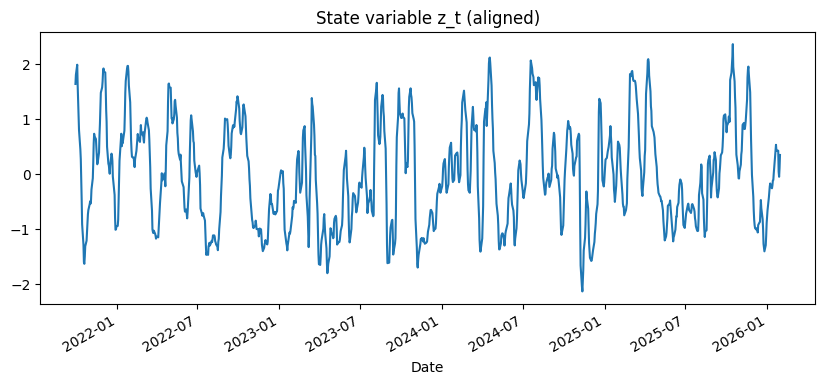

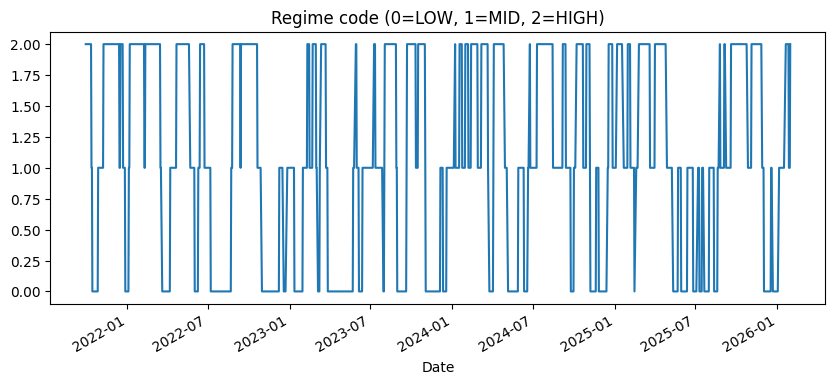

In [ ]:
z = build_state_z_from_iv(iv, freq=REGIME_FREQ, smooth_window=SMOOTH_WINDOW, lam=EWMA_LAMBDA, use_zscore=True)
z_daily = z.reindex(R.index).ffill().dropna()

reg = regime_labels_from_state(z_daily, q=REGIME_Q, expanding=True, min_obs=252)

print(reg.value_counts())
z_daily.loc[reg.index].plot(title="State variable z_t (aligned)")
plt.show()

tmp = pd.DataFrame({"z": z_daily.loc[reg.index], "regime": reg})
tmp["regime_code"] = tmp["regime"].map({"LOW":0,"MID":1,"HIGH":2})
tmp["regime_code"].plot(title="Regime code (0=LOW, 1=MID, 2=HIGH)")
plt.show()


## 3) Static PCA (train) → factor portfolios → conditional performance (test)

In [ ]:
train = R.loc[:TRAIN_END_DEFAULT].dropna()
test  = R.loc[TEST_START_DEFAULT:].dropna()

mu_hat, Sigma_hat = weighted_mean_cov(train)
lam, V, vol, rho = correlation_pca(Sigma_hat.values)

W = pc_portfolio_weights_from_corr_pca(V[:, :K_BAR], vol, gross_norm=GROSS_NORM)
W.index = R.columns
W.columns = [f"PC{i+1}" for i in range(W.shape[1])]

F_test = factor_returns(test, W)

reg_test = reg.reindex(F_test.index).dropna()
F_test = F_test.loc[reg_test.index]

metrics_overall = {c: perf_metrics(F_test[c]) for c in F_test.columns}

def metrics_table(d: dict, key: str):
    return pd.Series({k: v.get(key, np.nan) for k,v in d.items()})

summary = pd.DataFrame({
    "CAGR": metrics_table(metrics_overall, "CAGR"),
    "ShR":  metrics_table(metrics_overall, "ShR"),
    "SoR":  metrics_table(metrics_overall, "SoR"),
    "MxDD": metrics_table(metrics_overall, "MxDD"),
    "Calmar": metrics_table(metrics_overall, "Calmar"),
})
summary


,CAGR,ShR,SoR,MxDD,Calmar
PC1,0.464766,1.917237,3.313490,-0.237543,1.956552
PC2,0.032074,0.340448,0.587405,-0.116319,0.275743
PC3,0.091649,0.878325,1.617868,-0.121531,0.754122
PC4,0.020631,0.234970,0.432208,-0.153614,0.134302
PC5,-0.061512,-0.464660,-0.782446,-0.250532,-0.245524
PC6,-0.038139,-0.341268,-0.499473,-0.209210,-0.182299
PC7,0.107217,1.116516,2.017885,-0.108529,0.987917


In [ ]:
W

,PC1,PC2,PC3,PC4,PC5,PC6,PC7
Ticker,,,,,,,
AAPL,0.101342,0.026858,-0.085608,0.038449,-0.072401,0.005049,-0.043955
MSFT,0.117419,0.024502,-0.116364,0.026875,-0.019607,0.041104,-0.061858
GOOGL,0.100904,0.012560,-0.109034,-0.050257,-0.049763,-0.041842,0.015573
AMZN,0.081463,-0.036113,-0.043958,-0.015141,-0.015058,0.006956,-0.055178
META,0.057619,-0.021458,-0.071971,-0.075008,0.000613,-0.080954,0.197837
CSCO,0.092626,0.195179,0.004077,0.093309,-0.123917,-0.156504,-0.016627
NVDA,0.059929,-0.027379,-0.008633,0.013187,-0.011605,0.021234,-0.070559
ORCL,0.072740,0.145460,0.037400,0.212700,0.266355,-0.103480,0.065459
PLTR,0.028138,-0.048776,0.074202,0.079729,-0.055584,0.025660,0.096882


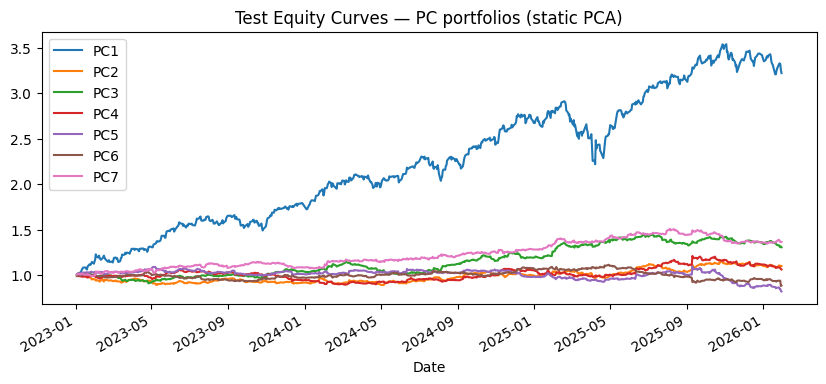

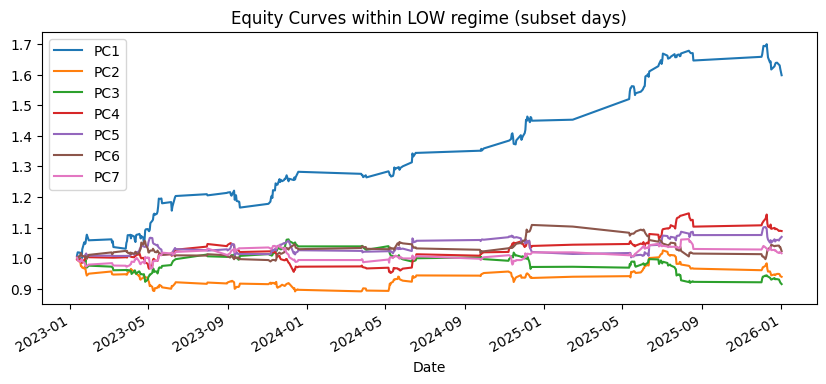

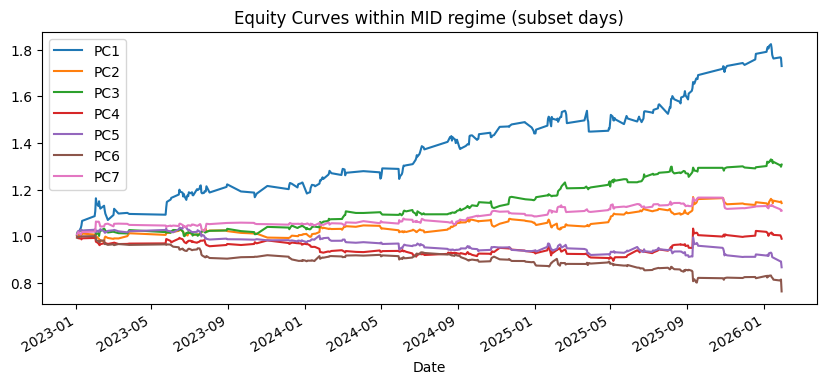

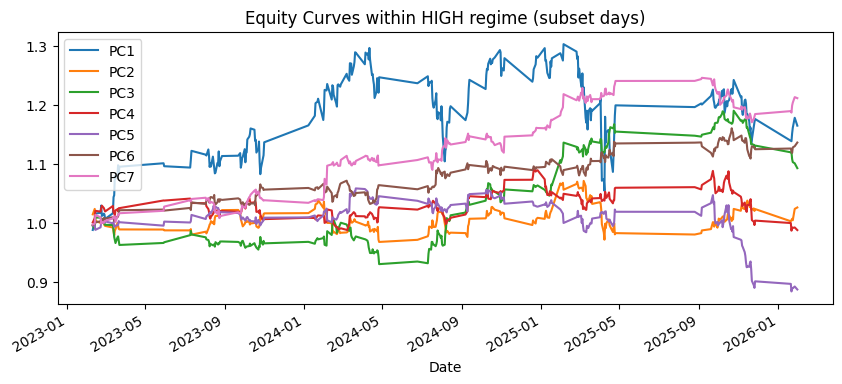

In [ ]:
((1+F_test.iloc[:, :7]).cumprod()).plot(title="Test Equity Curves — PC portfolios (static PCA)")
plt.show()

for rn in ["LOW","MID","HIGH"]:
    idx = reg_test[reg_test == rn].index
    cols = F_test.columns[:7]
    ((1+F_test.loc[idx, cols]).cumprod()).plot(title=f"Equity Curves within {rn} regime (subset days)")
    plt.show()


In [ ]:
px_B = download("QQQ", start=START, end=END, auto_adjust=False)["Adj Close"].dropna(how="all")
B_ret = linear_returns_from_prices(px_B)

[*********************100%***********************]  1 of 1 completed


In [ ]:
if isinstance(B_ret, pd.DataFrame):
    B_ret = abs(B_ret.iloc[:, 0])
elif isinstance(B_ret, np.ndarray) and B_ret.ndim == 2 and B_ret.shape[1] == 1:
    B_ret = abs(B_ret[:, 0])

res = choose_block_length_by_acf_matching(
    B_ret,
    candidates=[5,10,15,20,30],
    nlags=30,
    n_boot=300,
    use_abs=True,
    seed=1,
    stationary_bootstrap_indices_fn=stationary_bootstrap_indices,  # <-- il tuo helper
    distance="weighted"
)
print("Best L:", res["best_L"])
display(res["scores"])

Best L: 30


,0
5,0.050518
10,0.036840
15,0.028579
20,0.024466
30,0.018477


In [ ]:
px_B = download("QQQ", start=START, end=END, auto_adjust=False)["Adj Close"].dropna(how="all")
B_ret = linear_returns_from_prices(px_B)

if isinstance(B_ret, pd.DataFrame):
    B_ret = B_ret.iloc[:, 0]**2
elif isinstance(B_ret, np.ndarray) and B_ret.ndim == 2 and B_ret.shape[1] == 1:
    B_ret = B_ret[:, 0]**2

res = choose_block_length_by_acf_matching(
    B_ret,
    candidates=[5,10,15,20,30],
    nlags=30,
    n_boot=300,
    use_abs=True,
    seed=1,
    stationary_bootstrap_indices_fn=stationary_bootstrap_indices,  # <-- il tuo helper
    distance="weighted"
)
print("Best L:", res["best_L"])
display(res["scores"])

[*********************100%***********************]  1 of 1 completed


Best L: 30


,0
5,0.044727
10,0.032276
15,0.024221
20,0.023893
30,0.016105


In [ ]:
L_pw = politis_white_block_length(B_ret, use_abs=True)
print("PW suggested mean block length:", L_pw)

PW suggested mean block length: 39


## 4) Stationary bootstrap (Politis–Romano) for uncertainty of metrics
Bootstrap jointly (PC returns + state variable) by resampling time indices, preserving dependence.


In [ ]:
# ============================================================
# Bootstrap CIs — ALL selected PCs (first 7) and key metrics
# (Politis–Romano stationary bootstrap)
# ============================================================

PCS = [c for c in F_test.columns if c.startswith("PC")][:7]
KEYS = ["CAGR", "ShR", "SoR", "Calmar", "Martin", "MxDD"]

df_joint = pd.concat([F_test[PCS], z_daily.reindex(F_test.index).rename("z")], axis=1).dropna()
print("Joint test shape:", df_joint.shape)

N_BOOT = 1000
AVG_BLOCK = 39.0
sims = stationary_bootstrap_series(df_joint.reset_index(drop=True), n_boot=N_BOOT, avg_block_len=AVG_BLOCK, seed=1)

for key in KEYS:
    print("\n====================", key, "====================")
    for regime_name in ["overall","LOW","MID","HIGH"]:
        display(bootstrap_ci_table(key, regime_name).head(10))


Joint test shape: (772, 8)

==================== CAGR ====================


,mean,p05,p50,p95,n
PC,,,,,
PC1,0.471968,0.250767,0.469695,0.713052,1000
PC7,0.109631,0.027137,0.109842,0.189770,1000
PC3,0.094890,-0.028891,0.093484,0.224372,1000
PC2,0.033703,-0.051564,0.029901,0.126213,1000
PC4,0.022984,-0.082363,0.018332,0.137463,1000
PC6,-0.032464,-0.114237,-0.033095,0.049737,1000
PC5,-0.059861,-0.155099,-0.059102,0.029618,1000


,mean,p05,p50,p95,n
PC,,,,,
PC1,0.744185,0.399723,0.721521,1.154155,1000
PC4,0.082128,-0.126751,0.076967,0.314328,1000
PC5,0.059394,-0.124222,0.062996,0.242079,1000
PC7,0.053967,-0.076795,0.049530,0.187545,1000
PC6,-0.027981,-0.193514,-0.033446,0.152391,1000
PC2,-0.041270,-0.205880,-0.050350,0.161156,1000
PC3,-0.067764,-0.221624,-0.072623,0.111357,1000


,mean,p05,p50,p95,n
PC,,,,,
PC1,0.611298,0.280740,0.601639,0.982196,1000
PC3,0.292413,0.125869,0.287196,0.476076,1000
PC2,0.160840,-0.001834,0.153133,0.355108,1000
PC7,0.135864,-0.007069,0.123620,0.317596,1000
PC4,0.022956,-0.140073,0.010039,0.226161,1000
PC5,-0.115397,-0.243727,-0.122700,0.031623,1000
PC6,-0.170870,-0.321557,-0.176976,0.010285,1000


,mean,p05,p50,p95,n
PC,,,,,
PC1,0.179898,-0.231055,0.160334,0.655081,1000
PC7,0.150606,-0.034824,0.145145,0.349962,1000
PC6,0.129515,0.012833,0.131407,0.242455,1000
PC3,0.103930,-0.122628,0.084214,0.372455,1000
PC2,0.006433,-0.146230,0.007863,0.175896,1000
PC4,-0.020834,-0.158577,-0.025496,0.132191,1000
PC5,-0.102510,-0.267779,-0.100485,0.063669,1000


...


==================== MxDD ====================


,mean,p05,p50,p95,n
PC,,,,,
PC7,-0.098981,-0.163186,-0.098363,-0.048798,1000
PC3,-0.156427,-0.260361,-0.143838,-0.089391,1000
PC2,-0.159147,-0.260245,-0.150565,-0.087903,1000
PC4,-0.186032,-0.307358,-0.173762,-0.099948,1000
PC1,-0.192376,-0.282251,-0.188748,-0.107962,1000
PC6,-0.209532,-0.353070,-0.201110,-0.097647,1000
PC5,-0.269505,-0.445236,-0.259572,-0.121622,1000


,mean,p05,p50,p95,n
PC,,,,,
PC1,-0.056083,-0.085129,-0.051259,-0.035065,1000
PC7,-0.077352,-0.130874,-0.071196,-0.041693,1000
PC5,-0.096014,-0.177354,-0.086619,-0.051274,1000
PC4,-0.106005,-0.181800,-0.098938,-0.053974,1000
PC6,-0.125062,-0.223910,-0.119142,-0.055763,1000
PC2,-0.148139,-0.249063,-0.140857,-0.068665,1000
PC3,-0.150612,-0.248203,-0.143129,-0.070216,1000


,mean,p05,p50,p95,n
PC,,,,,
PC3,-0.044616,-0.070898,-0.042044,-0.028530,1000
PC7,-0.057068,-0.101268,-0.054118,-0.025518,1000
PC2,-0.065286,-0.108651,-0.059733,-0.037940,1000
PC1,-0.086843,-0.130241,-0.082342,-0.056802,1000
PC4,-0.105968,-0.184865,-0.099363,-0.052030,1000
PC5,-0.166284,-0.266697,-0.161771,-0.081956,1000
PC6,-0.206244,-0.336808,-0.201360,-0.080395,1000


,mean,p05,p50,p95,n
PC,,,,,
PC6,-0.051423,-0.092545,-0.044309,-0.030094,1000
PC7,-0.062336,-0.109879,-0.059230,-0.033111,1000
PC3,-0.110237,-0.200500,-0.101584,-0.052654,1000
PC4,-0.115912,-0.204440,-0.108019,-0.055948,1000
PC2,-0.116488,-0.207372,-0.107941,-0.054674,1000
PC5,-0.169756,-0.302108,-0.162541,-0.060873,1000
PC1,-0.195541,-0.346473,-0.185668,-0.098715,1000


## 5) Walk‑forward PCA (rolling re‑estimation)

WF factor returns shape: (772, 7)  | net: (772, 7)


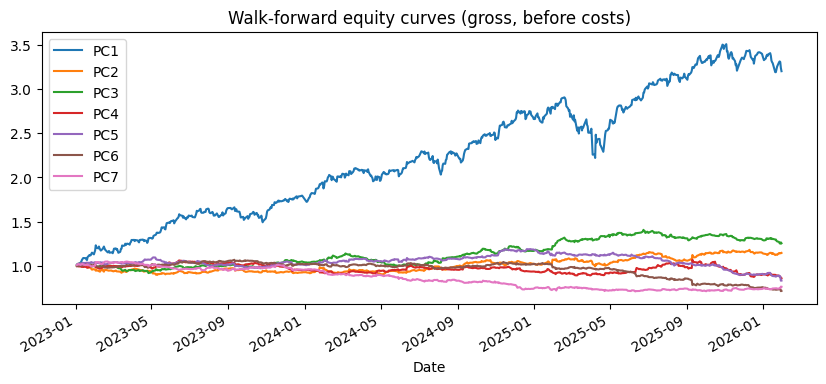

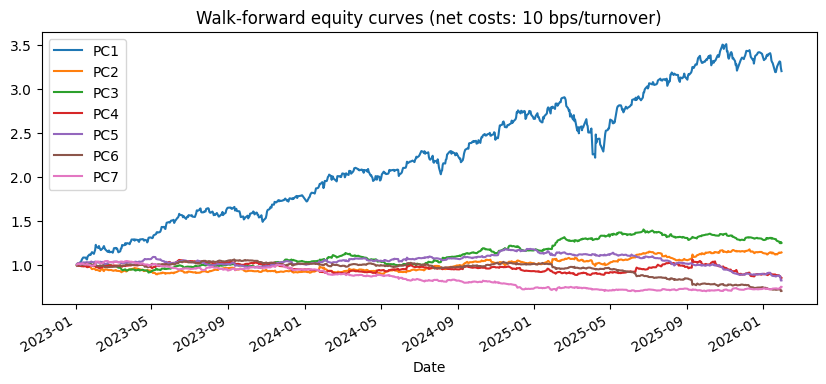

regime,HIGH,LOW,MID,overall
PC,,,,
PC1,0.678270,3.471449,2.769428,1.919532
PC2,0.449778,-0.727980,1.410389,0.450741
PC3,0.590239,-1.047756,2.362521,0.768188
PC4,-0.523206,0.579194,-0.873328,-0.365598
PC5,-0.273223,0.785520,-1.789454,-0.557128
PC6,-0.622401,-1.343181,-1.365741,-1.112643
PC7,-0.957742,-2.559479,0.343578,-0.886553


regime,HIGH,LOW,MID,overall
PC,,,,
PC1,2.475173,48.275545,32.268870,10.182329
PC2,1.212427,-1.161057,8.721436,0.754933
PC3,1.722337,-1.440704,22.493802,1.463657
PC4,-1.526121,1.649947,-1.390759,-0.521839
PC5,-0.672632,2.437306,-2.648513,-0.633372
PC6,-0.971406,-1.876025,-2.784410,-0.834313
PC7,-1.240546,-1.482443,0.579754,-0.401486


regime,HIGH,LOW,MID,overall
PC,,,,
PC1,0.678077,3.470714,2.769077,1.919202
PC2,0.448827,-0.730007,1.409037,0.449374
PC3,0.588618,-1.051022,2.360035,0.765771
PC4,-0.530941,0.573206,-0.881651,-0.373074
PC5,-0.298052,0.773005,-1.809053,-0.575761
PC6,-0.655346,-1.393717,-1.387343,-1.145923
PC7,-0.974662,-2.596078,0.291157,-0.921825


regime,HIGH,LOW,MID,overall
PC,,,,
PC1,2.473810,48.260596,32.262420,10.179311
PC2,1.208539,-1.163462,8.707938,0.751536
PC3,1.716386,-1.443817,22.445262,1.457072
PC4,-1.541518,1.628865,-1.389678,-0.526435
PC5,-0.710861,2.390321,-2.628492,-0.645739
PC6,-1.004339,-1.939841,-2.768464,-0.843855
PC7,-1.252687,-1.485239,0.441001,-0.406536


,cos_PC1,cos_PC2,cos_PC3,cos_PC4,cos_PC5,cos_PC6,cos_PC7,to_PC1,to_PC2,to_PC3,to_PC4,to_PC5,to_PC6,to_PC7
rebalance,,,,,,,,,,,,,,
2023-04-01,0.999794,0.999729,0.996894,0.992619,0.954284,0.941619,0.405535,0.019045,0.031934,0.079749,0.126789,0.320143,0.368340,1.097671
2023-07-01,0.999875,0.999474,0.996343,0.986595,0.990890,0.992656,0.779235,0.013546,0.040991,0.071192,0.167955,0.153913,0.143319,0.625218
2023-10-01,0.999893,0.999698,0.999204,0.986734,0.977056,0.991171,0.914928,0.011502,0.026004,0.032914,0.136776,0.221493,0.145483,0.376094
2024-01-01,0.999784,0.999824,0.999048,0.987675,0.982088,0.993906,0.900448,0.016068,0.021813,0.046435,0.152486,0.225472,0.128719,0.471238
2024-04-01,0.999937,0.999704,0.999155,0.976557,0.978936,0.995175,0.992090,0.010675,0.029568,0.039694,0.186376,0.237452,0.109916,0.139178


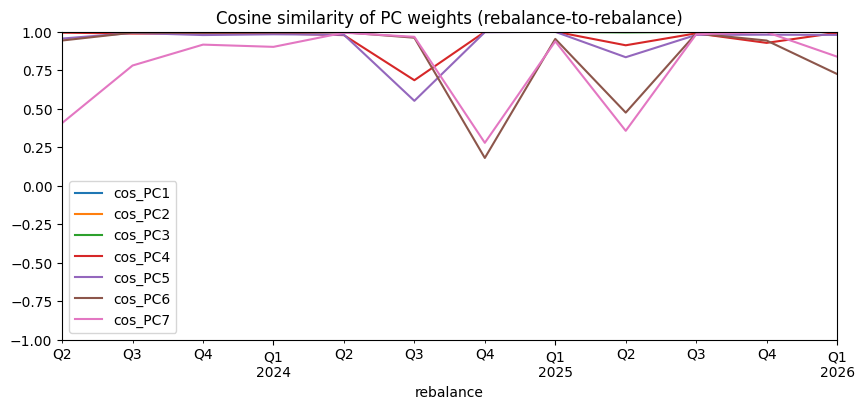

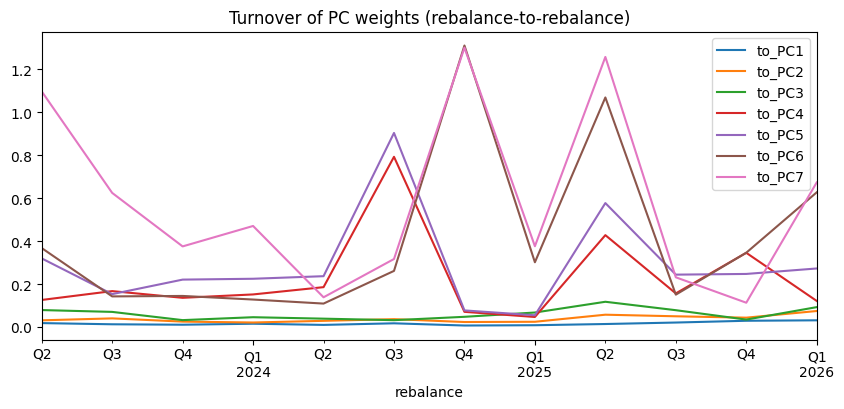

In [ ]:
F_wf, F_wf_net, W_hist = walk_forward_pca(
    R=R,
    start_test=TEST_START_DEFAULT,
    train_years=WF_TRAIN_YEARS,
    step_months=WF_STEP_MONTHS,
    k=WF_K_CHOICE,
    gross_norm=GROSS_NORM,
    tc_bps=TC_BPS
)

print("WF factor returns shape:", F_wf.shape, " | net:", F_wf_net.shape)

PCS_WF = [c for c in F_wf.columns if c.startswith("PC")][:7]

if not F_wf.empty:
    ((1+F_wf[PCS_WF]).cumprod()).plot(title="Walk-forward equity curves (gross, before costs)")
    plt.show()
    ((1+F_wf_net[PCS_WF]).cumprod()).plot(title=f"Walk-forward equity curves (net costs: {TC_BPS} bps/turnover)")
    plt.show()

    reg_wf = reg.reindex(F_wf.index)
    m_wf_g = {"overall": {c: perf_metrics(F_wf[c]) for c in PCS_WF}}
    m_wf_n = {"overall": {c: perf_metrics(F_wf_net[c]) for c in PCS_WF}}
    for rn in ["LOW","MID","HIGH"]:
        idx = reg_wf[reg_wf == rn].index
        m_wf_g[rn] = {c: perf_metrics(F_wf.loc[idx, c]) for c in PCS_WF}
        m_wf_n[rn] = {c: perf_metrics(F_wf_net.loc[idx, c]) for c in PCS_WF}

    def table_from_metrics(mdict, key):
        rows = []
        for regime_name, d in mdict.items():
            for pc, mets in d.items():
                rows.append({"regime": regime_name, "PC": pc, key: mets.get(key, np.nan)})
        return pd.DataFrame(rows).pivot(index="PC", columns="regime", values=key)

    display(table_from_metrics(m_wf_g, "ShR"))
    display(table_from_metrics(m_wf_g, "Martin"))
    display(table_from_metrics(m_wf_n, "ShR"))
    display(table_from_metrics(m_wf_n, "Martin"))

# --- Stability diagnostics: loadings/portfolio stability across rebalances ---
def cosine_sim(a, b):
    a = np.asarray(a, float).ravel()
    b = np.asarray(b, float).ravel()
    na = np.linalg.norm(a); nb = np.linalg.norm(b)
    if na == 0 or nb == 0:
        return np.nan
    return float(np.dot(a, b) / (na * nb))

if len(W_hist) >= 2:
    pcs = [f"PC{i+1}" for i in range(min(7, WF_K_CHOICE))]
    rows = []
    for i in range(1, len(W_hist)):
        W_prev = W_hist[i-1]["W"][pcs].values
        W_now  = W_hist[i]["W"][pcs].values

        # sign alignment per-PC
        for j in range(W_now.shape[1]):
            if cosine_sim(W_prev[:, j], W_now[:, j]) < 0:
                W_now[:, j] *= -1

        rows.append({
            "rebalance": W_hist[i]["rebalance"],
            **{f"cos_PC{j+1}": cosine_sim(W_prev[:, j], W_now[:, j]) for j in range(W_now.shape[1])},
            **{f"to_PC{j+1}": turnover(W_prev[:, j], W_now[:, j]) for j in range(W_now.shape[1])},
        })

    stab = pd.DataFrame(rows).set_index("rebalance")
    display(stab.head())

    stab.filter(like="cos_").plot(title="Cosine similarity of PC weights (rebalance-to-rebalance)")
    plt.ylim(-1, 1)
    plt.show()

    stab.filter(like="to_").plot(title="Turnover of PC weights (rebalance-to-rebalance)")
    plt.show()

## Roadmap / TODO (planned extensions)

- **Regime state variable** refinement
- More realistic **transaction costs** (bid/ask + slippage proxies) and turnover-aware net performance
- **Cross-country** replication (US/EU/UK/JP) with a unified regime signal; investigate regime-dependent dominance of PCs
- **Overlay** ideas (risk-management / drawdown control / volatility scaling) with proper OOS evaluation
- Sensitivity analysis: regime definition, block-length choice, k selection, shrinkage intensity